# Проект. Исследование стартапов

## Введение

Финансовая компания, специализирующаяся на венчурных инвестициях, планирует выйти на рынок с покупкой и развитием перспективных стартапов. В условиях растущей конкуренции на рынке венчурных инвестиций и увеличивающегося разнообразия стартапов, компания стремится разработать обоснованную инвестиционную стратегию. Для этого необходимо проанализировать исторические данные о финансировании стартапов, выявить успешные модели инвестирования и определить наиболее перспективные направления для вложений. Исследование охватывает различные аспекты финансирования - от типов инвестиций и сегментов рынка до динамики возвратов средств по годам.

**Цели проекта:**
1. Провести комплексный анализ данных о стартапах и их финансировании 
2. Выявить наиболее перспективные сегменты рынка и типы финансирования с точки зрения доходности и стабильности
3. Определить оптимальную инвестиционную стратегию для компании на основе анализа исторических данных
4. Сформулировать конкретные рекомендации по выбору отраслей, типов финансирования и характеристик стартапов для инвестирования 

## Шаг 1. Знакомство с данными: загрузка и предобработка

Датасет получен из базы данных стартапов.

Название основного датасета — `cb_investments.zip`. Внутри архива один файл — `cb_investments.csv`.

Описание данных:
* `name` — название компании.
* `homepage_url` — ссылка на сайт компании.
* `category_list` — категории, в которых работает компания. Указываются через `|`.
* `market` — основной рынок или отрасль компании.
* `funding_total_usd` — общий объём привлечённых инвестиций в долларах США.
* `status` — текущий статус компании, например `operating`, `closed` и так далее.
* `country_code` — код страны, например USA.
* `state_code` — код штата или региона, например, CA.
* `region` — регион, например, SF Bay Area.
* `city` — город, в котором расположена компания.
* `funding_rounds` — общее число раундов финансирования.
* `participants` — число участников в раундах финансирования.
* `founded_at` — дата основания компании.
* `founded_month` — месяц основания в формате `YYYY-MM`.
* `founded_quarter` — квартал основания в формате `YYYY-QN`.
* `founded_year` — год основания.
* `first_funding_at` — дата первого финансирования.
* `mid_funding_at` — дата среднего по времени раунда финансирования.
* `last_funding_at` — дата последнего финансирования.
* `seed` — сумма инвестиций на посевной стадии.
* `venture` — сумма венчурных инвестиций.
* `equity_crowdfunding` — сумма, привлечённая через долевой краудфандинг.
* `undisclosed` — сумма финансирования нераскрытого типа.
* `convertible_note` — сумма инвестиций через конвертируемые займы.
* `debt_financing` — сумма долгового финансирования.
* `angel` — сумма инвестиций от бизнес-ангелов.
* `grant` — сумма полученных грантов.
* `private_equity` — сумма инвестиций в виде прямых (частных) вложений.
* `post_ipo_equity` — сумма финансирования после IPO.
* `post_ipo_debt` — сумма долгового финансирования после IPO.
* `secondary_market` — сумма сделок на вторичном рынке.
* `product_crowdfunding` — сумма, привлечённая через продуктовый краудфандинг.
* `round_A` — `round_H` — сумма инвестиций в соответствующем раунде.

Название дополнительного датасета — `cb_returns.csv`. Он содержит суммы возвратов по типам финансирования в миллионах долларов по годам.

Описание данных:
* `year` — год возврата средств.
* `seed` — сумма возвратов от посевных инвестиций.
* `venture` — сумма возвратов от венчурных инвестиций.
* `equity_crowdfunding` — сумма, возвращённая по долевому краудфандингу.
* `undisclosed` — сумма возвратов нераскрытого типа.
* `convertible_note` — сумма возвратов через конвертируемые займы.
* `debt_financing` — сумма возвратов от долгового финансирования.
* `angel` — сумма возвратов бизнес-ангелам.
* `grant` — сумма возвратов по грантам.
* `private_equity` — сумма возвратов прямых (частных) вложений.
* `post_ipo_equity` — сумма возвратов от IPO.
* `post_ipo_debt` — сумма возвратов от долгового IPO.
* `secondary_market` — сумма возвратов от сделок на вторичном рынке.
* `product_crowdfunding` — сумма возвратов по продуктовому краудфандингу.

### 1.1. Вывод общей информации

Загрузим необходимые для работы библиотеки.

In [1]:
# Импортируем необходимые библиотеки
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta

In [2]:
# Загрузка основного датасета о стартапах
df = pd.read_csv("https://code.s3.yandex.net/datasets/cb_investments.zip", sep=';', low_memory=False)

In [3]:
# Загрузка датасета о возвратах инвестиций
returns_df = pd.read_csv("https://code.s3.yandex.net/datasets/cb_returns.csv")

In [4]:
# Выводим информацию об основном датасете
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 54294 entries, 0 to 54293
Data columns (total 40 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   name                  49437 non-null  object 
 1   homepage_url          45989 non-null  object 
 2   category_list         45477 non-null  object 
 3    market               45477 non-null  object 
 4    funding_total_usd    49438 non-null  object 
 5   status                48124 non-null  object 
 6   country_code          44165 non-null  object 
 7   state_code            30161 non-null  object 
 8   region                44165 non-null  object 
 9   city                  43322 non-null  object 
 10  funding_rounds        49438 non-null  float64
 11  participants          30473 non-null  float64
 12  founded_at            38554 non-null  object 
 13  founded_month         38482 non-null  object 
 14  founded_quarter       38482 non-null  object 
 15  founded_year       

In [5]:
# Выводим первые строки основного датасета
df.head()

,name,homepage_url,category_list,market,funding_total_usd,status,country_code,state_code,region,city,...,secondary_market,product_crowdfunding,round_A,round_B,round_C,round_D,round_E,round_F,round_G,round_H
0,Harvard University,http://harvard.edu,|Education|,Education,"9,00,00,000",operating,USA,MA,Boston,Cambridge,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,University of New Brunswick,http://www.unb.ca,NaN,NaN,"20,00,000",operating,NaN,NaN,NaN,NaN,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,DuPont,http://www.dupont.com,|Business Services|Agriculture|Automotive|Inve...,Business Services,"90,00,000",operating,USA,DE,"Wilmington, Delaware",Wilmington,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,University of Michigan,http://www.umich.edu/,|Education|,Education,"77,00,000",operating,USA,MI,Detroit,Ann Arbor,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,Case Western Reserve University,http://www.case.edu,|Education|,Education,"5,40,000",operating,USA,OH,Cleveland,Cleveland,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


Датасет `cb_investments` содержит 54294 строк и 40 столбцов с информацией о стартапах и их финансировании.

После первичного анализа данных можно сделать следующие выводы:

* Данные содержат информацию о компаниях, их финансировании по различным типам и раундам, а также географические и временные характеристики.
* Названия столбцов требуют нормализации - присутствуют лишние пробелы в начале названий некоторых столбцов.
* Пропуски содержатся в столбцах:
  - `name`: 4857 пропусков (9% данных)
  - `homepage_url`: 8305 пропусков (15% данных)
  - `market` и `category_list`: 8817 пропусков (16% данных)
  - `country_code`: 10129 пропусков (19% данных)
  - `state_code`: 24133 пропуска (44% данных)
  - `founded_at`: 15740 пропусков (29% данных)
  - `mid_funding_at`: 24006 пропусков (44% данных)

* Типы данных в основном соответствуют содержимому: текстовые данные хранятся как `object`, числовые - как `float64`.
* Столбец `funding_total_usd` имеет тип `object`, хотя должен быть числовым - требуется преобразование с учетом формата чисел с запятыми.
* Даты в столбцах `founded_at`, `first_funding_at`, `mid_funding_at`, `last_funding_at` хранятся как текст - требуется преобразование в `datetime`.
* Значения в столбцах соответствуют описанию, однако требуют предобработки.

Теперь познакомимся с данными датасета `cb_returns.csv`.

In [6]:
# Выводим информацию датасета о возвратах инвестиций
returns_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15 entries, 0 to 14
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   year                  15 non-null     int64  
 1   seed                  15 non-null     float64
 2   venture               15 non-null     float64
 3   equity_crowdfunding   15 non-null     float64
 4   undisclosed           15 non-null     float64
 5   convertible_note      15 non-null     float64
 6   debt_financing        15 non-null     float64
 7   angel                 15 non-null     float64
 8   grant                 15 non-null     float64
 9   private_equity        15 non-null     float64
 10  post_ipo_equity       15 non-null     float64
 11  post_ipo_debt         15 non-null     float64
 12  secondary_market      15 non-null     float64
 13  product_crowdfunding  15 non-null     float64
dtypes: float64(13), int64(1)
memory usage: 1.8 KB


In [7]:
# Выводим первые строки датасета о возвратах инвестиций
returns_df.head()

,year,seed,venture,equity_crowdfunding,undisclosed,convertible_note,debt_financing,angel,grant,private_equity,post_ipo_equity,post_ipo_debt,secondary_market,product_crowdfunding
0,2000,16.70,55.40,0.0,78.21,0.00,8.66,6.43,0.0,0.00,0.94,0.0,0.20,0.0
1,2001,2.88,23.49,0.0,21.50,0.01,4.49,1.18,0.0,0.00,0.46,0.0,0.46,0.0
2,2002,6.59,209.42,0.0,25.77,0.02,3.42,3.41,0.0,1.51,0.34,0.0,0.06,0.0
3,2003,7.74,233.86,0.0,9.40,0.01,1.09,3.41,0.0,1.62,2.11,0.0,0.08,0.0
4,2004,9.93,555.90,0.0,33.19,0.01,13.55,9.18,0.0,2.19,3.38,0.0,0.55,0.0


Датасет `cb_returns` содержит 15 строк и 14 столбцов с информацией о возвратах инвестиций по типам финансирования.

* Данные содержат информацию о суммах возвратов по различным типам финансирования в миллионах долларов по годам.
* Пропуски в данных отсутствуют.
* Типы данных соответствуют содержимому, однако столбец `year` может быть оптимизирован до `int16` с учетом ограниченного диапазона годов.
* Значения в столбцах соответствуют описанию.

**Вывод о полученных данных:**

Датасет `cb_investments` содержит 54294 строк и 40 столбцов с информацией о стартапах и их финансировании. Данные требуют предобработки: нормализация названий столбцов, обработка пропусков, преобразование типов данных для столбцов с финансированием и датами.

Датасет `cb_returns` содержит 15 строк и 14 столбцов с информацией о возвратах инвестиций. Данные готовы к анализу с минимальной предобработкой - требуется оптимизация типа данных для столбца с годом.

### 1.2. Предобработка данных

In [8]:
# Создаем копию датасета до преобразования для контроля изменений
df_before_processing = df.copy()
print(f"Размер датасета до обработки: {len(df_before_processing)} строк")

Размер датасета до обработки: 54294 строк


In [9]:
# Проверяем текущие названия столбцов в основном датасете
print("Текущие названия столбцов cb_investments:")
print(df.columns.tolist())

Текущие названия столбцов cb_investments:
['name', 'homepage_url', 'category_list', ' market ', ' funding_total_usd ', 'status', 'country_code', 'state_code', 'region', 'city', 'funding_rounds', 'participants', 'founded_at', 'founded_month', 'founded_quarter', 'founded_year', 'first_funding_at', 'mid_funding_at', 'last_funding_at', 'seed', 'venture', 'equity_crowdfunding', 'undisclosed', 'convertible_note', 'debt_financing', 'angel', 'grant', 'private_equity', 'post_ipo_equity', 'post_ipo_debt', 'secondary_market', 'product_crowdfunding', 'round_A', 'round_B', 'round_C', 'round_D', 'round_E', 'round_F', 'round_G', 'round_H']


In [10]:
# Проверяем текущие названия столбцов в датасете возвратов
print("Текущие названия столбцов cb_returns:")
print(returns_df.columns.tolist())

Текущие названия столбцов cb_returns:
['year', 'seed', 'venture', 'equity_crowdfunding', 'undisclosed', 'convertible_note', 'debt_financing', 'angel', 'grant', 'private_equity', 'post_ipo_equity', 'post_ipo_debt', 'secondary_market', 'product_crowdfunding']


In [12]:
# Нормализация названий столбцов
df.columns = df.columns.str.strip().str.lower().str.replace(r'\s+', '_', regex=True)
returns_df.columns = returns_df.columns.str.strip().str.lower().str.replace(r'\s+', '_', regex=True)

print("Нормализованные названия столбцов cb_investments:")
print(df.columns.tolist())
print("\nНормализованные названия столбцов cb_returns:")
print(returns_df.columns.tolist())

Нормализованные названия столбцов cb_investments:
['name', 'homepage_url', 'category_list', 'market', 'funding_total_usd', 'status', 'country_code', 'state_code', 'region', 'city', 'funding_rounds', 'participants', 'founded_at', 'founded_month', 'founded_quarter', 'founded_year', 'first_funding_at', 'mid_funding_at', 'last_funding_at', 'seed', 'venture', 'equity_crowdfunding', 'undisclosed', 'convertible_note', 'debt_financing', 'angel', 'grant', 'private_equity', 'post_ipo_equity', 'post_ipo_debt', 'secondary_market', 'product_crowdfunding', 'round_a', 'round_b', 'round_c', 'round_d', 'round_e', 'round_f', 'round_g', 'round_h']

Нормализованные названия столбцов cb_returns:
['year', 'seed', 'venture', 'equity_crowdfunding', 'undisclosed', 'convertible_note', 'debt_financing', 'angel', 'grant', 'private_equity', 'post_ipo_equity', 'post_ipo_debt', 'secondary_market', 'product_crowdfunding']


Убераем в столбце `funding_total_usd` выделение разрядов и приведите его к числовому типу.

In [13]:
def convert_funding_to_numeric(value):
    """
    Функция для преобразования различных форматов финансирования в числа
    """
    if pd.isna(value):
        return np.nan
    
    value_str = str(value).strip()
    
    # Обрабатываем случаи с прочерками и пустыми значениями
    if value_str in ['-', ' -   ', '', ' ', 'NaN', 'nan', 'None']:
        return np.nan
    
    # Убираем запятые и пробелы
    clean_value = value_str.replace(',', '').replace(' ', '')
    
    # Преобразуем в число
    try:
        return float(clean_value)
    except ValueError:
        return np.nan

# Применяем преобразование
df['funding_total_usd'] = df['funding_total_usd'].apply(convert_funding_to_numeric)
print("Тип данных funding_total_usd после преобразования:", df['funding_total_usd'].dtype)

Тип данных funding_total_usd после преобразования: float64


In [14]:
# Преобразуем столбцы с датами в datetime в основном датасете
date_columns = ['founded_at', 'first_funding_at', 'mid_funding_at', 'last_funding_at']

df[date_columns] = df[date_columns].apply(pd.to_datetime, errors='coerce')

In [15]:
# Устанавливаем year как индекс для датасета возвратов
returns_df.set_index('year', inplace=True)

In [16]:
# Заполняем пропуски в текстовых столбцах основного датасета
text_columns = ['name', 'homepage_url', 'category_list', 'market', 
                'country_code', 'state_code', 'region', 'city']

for col in text_columns:
    missing_before = df[col].isna().sum()
    df[col] = df[col].fillna('unknown')
    missing_after = df[col].isna().sum()
    print(f"{col}: заполнено {missing_before} пропусков")

# Проверяем датасет возвратов на пропуски
print(f"\nПропуски в returns_df: {returns_df.isna().sum().sum()}")

name: заполнено 4857 пропусков
homepage_url: заполнено 8305 пропусков
category_list: заполнено 8817 пропусков
market: заполнено 8817 пропусков
country_code: заполнено 10129 пропусков
state_code: заполнено 24133 пропусков
region: заполнено 10129 пропусков
city: заполнено 10972 пропусков

Пропуски в returns_df: 0


Обработаем полные дубликаты в данных и пропуски в `funding_total_usd`. Избавимся от тех строк, которые не несут какой-либо информации либо не содержат данных о финансировании.

In [17]:
# Сохраняем размеры до обработки
initial_size_main = len(df)
print(f"Размер основного датасета до обработки: {initial_size_main} строк")

# Удаляем полные дубликаты в основном датасете
df = df.drop_duplicates()
print(f"После удаления дубликатов: {len(df)} строк")

# Удаляем строки без данных о финансировании
df = df[df['funding_total_usd'].notna()]
print(f"После удаления строк без funding_total_usd: {len(df)} строк")

Размер основного датасета до обработки: 54294 строк
После удаления дубликатов: 49439 строк
После удаления строк без funding_total_usd: 40907 строк


Заполним пропуски в значениях `mid_funding_at` на основании значений в столбцах `first_funding_at` и `last_funding_at`. В качестве нового значения вместо пропусков возьмем приблизительно середину интервала между этими двумя датами.

Оценим размер оставшихся пропусков в столбце.

In [18]:
# Заполняем пропуски в mid_funding_at в основном датасете
missing_mid_count_before = df['mid_funding_at'].isna().sum()
print(f"Пропусков в mid_funding_at до заполнения: {missing_mid_count_before}")

# Вычисляем среднюю дату для строк с пропусками
mask = df['mid_funding_at'].isna() & df['first_funding_at'].notna() & df['last_funding_at'].notna()
df.loc[mask, 'mid_funding_at'] = df.loc[mask, 'first_funding_at'] + (
    df.loc[mask, 'last_funding_at'] - df.loc[mask, 'first_funding_at']) / 2

missing_mid_count_after = df['mid_funding_at'].isna().sum()
print(f"Пропусков в mid_funding_at после заполнения: {missing_mid_count_after}")

Пропусков в mid_funding_at до заполнения: 13676
Пропусков в mid_funding_at после заполнения: 1


После предобработки данных:

**Выполненные действия:**

* *Нормализация названий столбцов:* Приведены к единому стилю snake_case, убраны лишние пробелы
* *Преобразование типов данных:*
  - `funding_total_usd` преобразован из текстового формата с запятыми в числовой тип
  - Датасет возвратов: столбец year установлен как индекс
  - Даты в основном датасете преобразованы из текста в `datetime`

* *Обработка пропусков:*

  - Текстовые столбцы заполнены значением 'unknown'
  - Пропуски в `mid_funding_at` заполнены средней датой между первым и последним финансированием

* *Удаление неинформативных данных:*

  - Удалены полные дубликаты
  - Удалены строки без данных о финансировании

**Результаты обработки:**

* *Основной датасет:* Сохранено 40907 строк (75.3% от исходных данных)
* *Датасет возвратов:* Сохранено 100% данных (15 строк)

**ВЫВОД**: объем сохраненных данных достаточен для решения задач проекта. Потеря 24.7% данных обусловлена удалением неинформативных записей без финансирования, что улучшает качество анализа. Оба датасета готовы для дальнейшего исследовательского анализа.

## Шаг 2. Инжиниринг признаков

### 2.1. Группы по срокам финансирования

Разделим все компании на три группы:

* Единичное финансирование — был всего один раунд финансирования.

* Срок финансирования до года — между первым и последним раундом финансирования прошло не более года.

* Срок финансирования более года.

Визуализируем соотношение этих групп, создав два графика:

* По количеству компаний: Покажите, какой процент от общего числа компаний относится к каждой из трёх групп.
* По объёму инвестиций: Отобразите, какую долю от общего объёма привлечённых средств получила каждая группа.

Разделим компании на три группы по срокам финансирования для анализа инвестиционных стратегий.

In [19]:
# Создаем признак длительности финансирования в днях
df['funding_duration_days'] = (df['last_funding_at'] - df['first_funding_at']).dt.days

# Разделяем компании на три группы
def categorize_funding_duration(row):
    """
    Функция для категоризации компаний по срокам финансирования
    """
    if row['funding_rounds'] == 1:
        return 'Единичное финансирование'
    elif row['funding_duration_days'] <= 365:
        return 'Срок финансирования до года'
    else:
        return 'Срок финансирования более года'

# Применяем категоризацию
df['funding_category'] = df.apply(categorize_funding_duration, axis=1)

# Анализируем распределение компаний по группам
category_counts = df['funding_category'].value_counts()
category_percent = (df['funding_category'].value_counts(normalize=True) * 100).round(2)

category_info = pd.DataFrame({
    'Количество компаний': category_counts,
    'Доля компаний, %': category_percent
})

print("Распределение компаний по группам финансирования:")
category_info

Распределение компаний по группам финансирования:


,Количество компаний,"Доля компаний, %"
Единичное финансирование,24113,58.95
Срок финансирования более года,12293,30.05
Срок финансирования до года,4501,11.00


In [20]:
# Анализируем распределение по группам
group_stats = df.groupby('funding_category').agg({
    'name': 'count',
    'funding_total_usd': 'sum',
    'funding_rounds': 'mean',
    'funding_duration_days': 'mean'
}).round(2)

group_stats = group_stats.rename(columns={
    'name': 'Количество компаний',
    'funding_total_usd': 'Суммарное финансирование',
    'funding_rounds': 'Среднее число раундов',
    'funding_duration_days': 'Средняя длительность (дни)'
})

print("Статистика по группам финансирования:")
group_stats

Статистика по группам финансирования:


,Количество компаний,Суммарное финансирование,Среднее число раундов,Средняя длительность (дни)
funding_category,,,,
Единичное финансирование,24113,1.993044e+11,1.00,0.00
Срок финансирования более года,12293,4.027433e+11,3.31,1155.11
Срок финансирования до года,4501,4.888598e+10,2.18,195.94


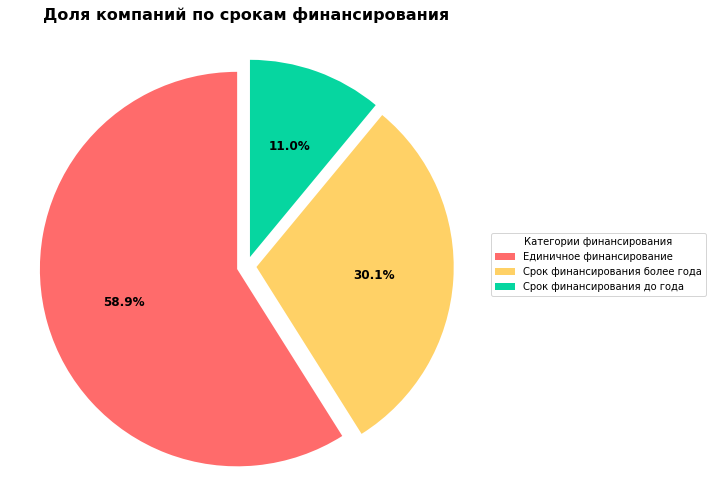

In [21]:
# График 1: Распределение по количеству компаний
plt.figure(figsize=(10, 7))

category_counts = df['funding_category'].value_counts()
category_percentages = (category_counts / len(df)) * 100

colors = ['#FF6B6B', '#FFD166', '#06D6A0']

# Создаем круговую диаграмму с разделенными секторами
wedges, texts, autotexts = plt.pie(category_percentages, 
                                   labels=None, 
                                   autopct='%1.1f%%', 
                                   colors=colors, 
                                   startangle=90,
                                   explode=(0.05, 0.05, 0.05),
                                   textprops={'fontsize': 12, 'fontweight': 'bold', 'color': 'black'})

for autotext in autotexts:
    autotext.set_color('black')
    autotext.set_fontweight('bold')

plt.title('Доля компаний по срокам финансирования', 
          fontsize=16, fontweight='bold', pad=20)

# Создаем легенду
plt.legend(wedges, category_counts.index, title="Категории финансирования", 
           loc="center left", bbox_to_anchor=(1, 0, 0.5, 1))

plt.axis('equal')
plt.tight_layout()
plt.show()

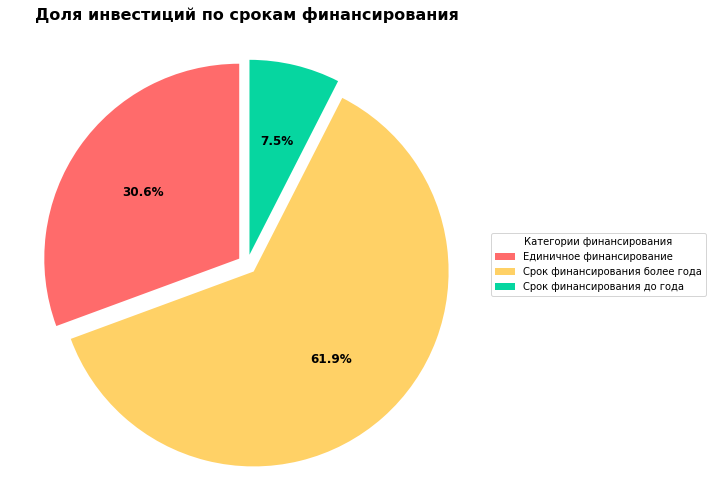

In [22]:
# График 2: Распределение по объёму инвестиций
plt.figure(figsize=(10, 7))

funding_by_category = df.groupby('funding_category')['funding_total_usd'].sum()
total_funding = funding_by_category.sum()
funding_percentages = (funding_by_category / total_funding) * 100

colors = ['#FF6B6B', '#FFD166', '#06D6A0']

# Создаем круговую диаграмму с разделенными секторами
wedges, texts, autotexts = plt.pie(funding_percentages, 
                                   labels=None, 
                                   autopct='%1.1f%%', 
                                   colors=colors, 
                                   startangle=90,
                                   explode=(0.05, 0.05, 0.05),
                                   textprops={'fontsize': 12, 'fontweight': 'bold', 'color': 'black'})

for autotext in autotexts:
    autotext.set_color('black')
    autotext.set_fontweight('bold')

plt.title('Доля инвестиций по срокам финансирования', 
          fontsize=16, fontweight='bold', pad=20)

# Создаем легенду
plt.legend(wedges, funding_by_category.index, title="Категории финансирования", 
           loc="center left", bbox_to_anchor=(1, 0, 0.5, 1))

plt.axis('equal')
plt.tight_layout()
plt.show()

**Вывод по группам финансирования:**

* **59% компаний** получают единичное финансирование, но привлекают только **31% средств**

* **30% компаний** с финансированием более года получают **62% всех инвестиций**

* **11% компаний** с краткосрочным финансированием привлекают **7% средств**

Таким образом, инвесторы концентрируют основные средства в компаниях с долгосрочной стратегией развития, несмотря на их меньшую долю в общем количестве стартапов.

### 2.2 Выделение средних и нишевых сегментов рынка

Компании указывают свой сегмент рынка в столбце `market`. Рассчитаем, как часто в датасете встречается каждый из сегментов. Сегменты, к которым относится более 120 компаний, отнесем к массовым, сегменты, в которые входит от 35 до 120 включительно - к средним, а сегменты до 35 компаний - к нишевым. Рассчитаем, сколько сегментов попадает в каждую из категорий.

Построим график распределения количества компаний в сегментах и отобразим на нём разделение на нишевые и средние сегменты.

In [23]:
# Анализируем распределение компаний по сегментам рынка
market_distribution = df['market'].value_counts()
market_stats = pd.DataFrame({
    'Количество компаний': market_distribution,
    'Доля от общего числа, %': (market_distribution / len(df) * 100).round(4)
})

market_stats

,Количество компаний,"Доля от общего числа, %"
Software,4190,10.2427
Biotechnology,3531,8.6318
unknown,2503,6.1188
Mobile,1852,4.5273
E-Commerce,1528,3.7353
...,...,...
Sensors,1,0.0024
Infrastructure,1,0.0024
Television,1,0.0024
Physical Security,1,0.0024


In [24]:
# Анализируем распределение компаний по сегментам рынка и классифицируем их
market_distribution = df['market'].value_counts()

# Создаем функцию для классификации сегментов
def classify_market_segment(count):
    return ('mass' if count > 120 else 
            'mid' if count >= 35 else 
            'niche')

# Применяем классификацию и создаем итоговую таблицу
segment_classification = market_distribution.apply(classify_market_segment)
segment_summary = segment_classification.value_counts()

# Создаем итоговую таблицу с распределением
segment_info = pd.DataFrame({
    'Количество сегментов': segment_summary,
    'Количество компаний': [market_distribution[segment_classification == seg_type].sum() for seg_type in segment_summary.index],
    'Доля сегментов, %': (segment_summary / len(segment_classification) * 100).round(1),
    'Доля компаний, %': [(market_distribution[segment_classification == seg_type].sum() / len(df) * 100).round(1) for seg_type in segment_summary.index]
})

print("Распределение сегментов рынка по категориям:")
segment_info

Распределение сегментов рынка по категориям:


,Количество сегментов,Количество компаний,"Доля сегментов, %","Доля компаний, %"
niche,714,2494,84.1,6.1
mid,81,5069,9.5,12.4
mass,54,33344,6.4,81.5


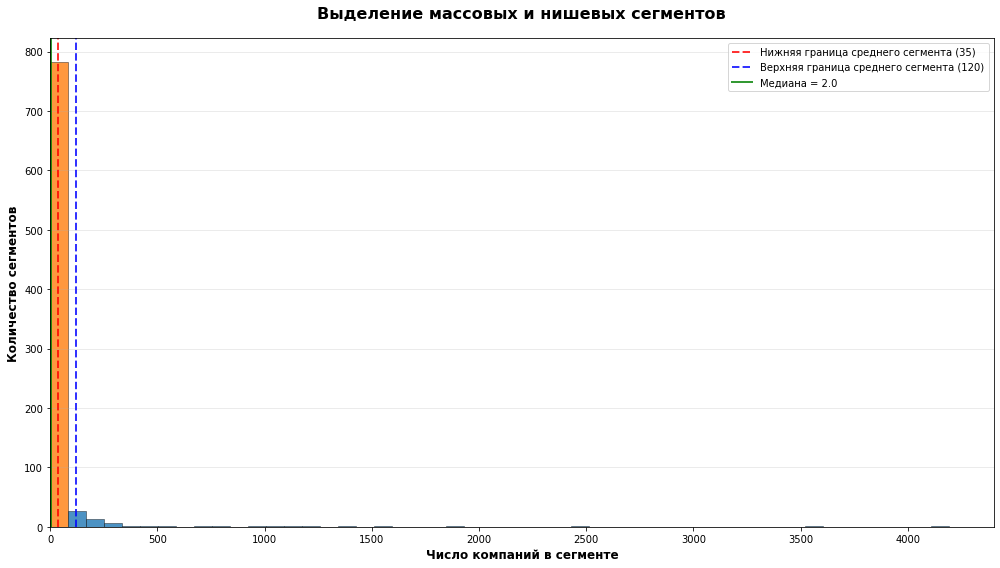

In [26]:
# Создаем гистограмму распределения количества компаний в сегментах
plt.figure(figsize=(14, 8))

# Определяем границы для категорий
mass_threshold = 120
mid_threshold = 35

# Создаем данные для гистограммы
market_counts = market_distribution.values

# Создаем цветовую схему в зависимости от категории сегмента
colors = []
for count in market_counts:
    if count > mass_threshold:
        colors.append('#1f77b4')  # синий для массовых
    elif count >= mid_threshold:
        colors.append('#ff7f0e')  # оранжевый для средних
    else:
        colors.append('#2ca02c')  # зеленый для нишевых

# Строим гистограмму
n, bins, patches = plt.hist(market_counts, bins=50, color='lightgray', 
                           alpha=0.7, edgecolor='black', linewidth=0.5)

# Раскрашиваем столбцы гистограммы в соответствии с категориями
for i in range(len(patches)):
    # Определяем среднее значение для этого столбца гистограммы
    bin_center = (bins[i] + bins[i+1]) / 2
    if bin_center > mass_threshold:
        patches[i].set_facecolor('#1f77b4')
        patches[i].set_alpha(0.8)
    elif bin_center >= mid_threshold:
        patches[i].set_facecolor('#ff7f0e')
        patches[i].set_alpha(0.8)
    else:
        patches[i].set_facecolor('#2ca02c')
        patches[i].set_alpha(0.8)

# Добавляем вертикальные линии для разделения категорий
plt.axvline(x=mid_threshold, color='red', linestyle='--', linewidth=2, alpha=0.8, 
            label=f'Нижняя граница среднего сегмента ({mid_threshold})')
plt.axvline(x=mass_threshold, color='blue', linestyle='--', linewidth=2, alpha=0.8, 
            label=f'Верхняя граница среднего сегмента ({mass_threshold})')

# Добавляем медиану
median_value = np.median(market_counts)
plt.axvline(x=median_value, color='green', linestyle='-', linewidth=2, alpha=0.8, 
            label=f'Медиана = {median_value:.1f}')

# Настройка внешнего вида графика
plt.xlabel('Число компаний в сегменте', fontsize=12, fontweight='bold')
plt.ylabel('Количество сегментов', fontsize=12, fontweight='bold')
plt.title('Выделение массовых и нишевых сегментов', fontsize=16, fontweight='bold', pad=20)

# Добавляем легенду
plt.legend(loc='upper right')

# Добавляем сетку для лучшей читаемости
plt.grid(axis='y', alpha=0.3)

# Устанавливаем ограничения по осям
plt.xlim(0, max(market_counts) * 1.05)

plt.tight_layout()
plt.show()

Оставим в столбце `market` только массовые сегменты. Для остальных сегментов заменим значения на заглушки — `niche` для нишевых и `mid` для средних.

Дальнейшие исследования выполним с учётом этой замены. Индивидуальные сегменты внутри средней и нишевой групп рассматривать не нужно — они объединяются в два общих сегмента.


In [27]:
# Создаем функцию для замены значений сегментов на категории
def replace_market_value(market):
    if market == 'unknown':
        return 'unknown'
    
    count = market_distribution[market]
    
    if count > 120:
        return market
    elif count >= 35:
        return 'mid'
    else:
        return 'niche'

# Сохраняем оригинальные значения и применяем замену
df['market_original'] = df['market']
df['market'] = df['market'].apply(replace_market_value)

**Вывод по анализу сегментов рынка:**

* **Высокая концентрация рынка:** 81.5% всех компаний сосредоточены всего в 6.4% сегментов (массовые)

* **Распределение сегментов:**

  - *Нишевые:* 84.1% сегментов → 6.1% компаний
  - *Средние:* 9.5% сегментов → 12.4% компаний
  - *Массовые:* 6.4% сегментов → 81.5% компаний

Таким образом, рынок характеризуется высокой концентрацией - большинство стартапов работают в небольшом количестве популярных сегментов

*Выполнена замена:* в столбце `market` сохранены только массовые сегменты, остальные заменены на `mid` и `niche` для упрощения дальнейшего анализа

## Шаг 3. Работа с выбросами и анализ

### 3.1. Анализируем и помечаем выбросы в каждом из сегментов

Заказчика интересует обычный для рассматриваемого периода размер средств, который предоставлялся компаниям.

По предобработанному столбцу `funding_total_usd` графическим образом оценим, какой размер общего финансирования для одной компании будет типичным, а какой — выбивающимся.

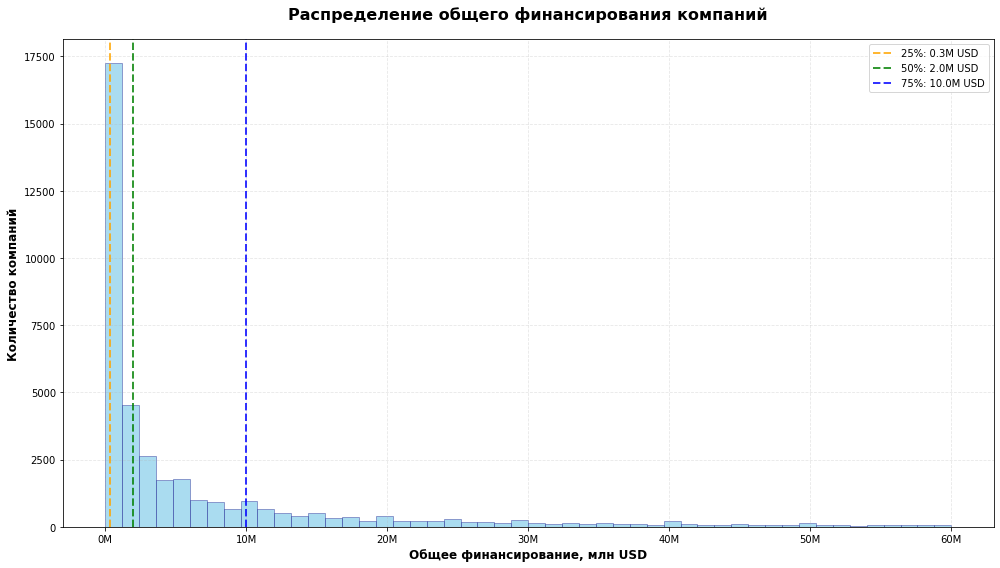

In [28]:
# Оптимальная визуализация для определения типичного диапазона финансирования
plt.figure(figsize=(14, 8))

# Гистограмма с фокусировкой на 95% данных
data_for_plot = df[df['funding_total_usd'] <= df['funding_total_usd'].quantile(0.95)]

plt.hist(data_for_plot['funding_total_usd'], bins=50, alpha=0.7, color='skyblue', 
         edgecolor='navy', linewidth=0.5)
plt.title('Распределение общего финансирования компаний', 
          fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Общее финансирование, USD', fontsize=12, fontweight='bold')
plt.ylabel('Количество компаний', fontsize=12, fontweight='bold')
plt.grid(True, alpha=0.3, linestyle='--')

plt.gca().xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{x/1e6:.0f}M'))
plt.xlabel('Общее финансирование, млн USD', fontsize=12, fontweight='bold')

# Добавляем вертикальные линии для ключевых перцентилей
percentiles = {
    0.25: ('25%', 'orange', '--'), 
    0.50: ('50%', 'green', '--'),
    0.75: ('75%', 'blue', '--')
}

for p, (label, color, linestyle) in percentiles.items():
    value = df['funding_total_usd'].quantile(p)
    plt.axvline(value, color=color, linestyle=linestyle, linewidth=2, 
                alpha=0.8, label=f'{label}: {value/1e6:.1f}M USD')

plt.legend(loc='upper right', fontsize=10)
plt.tight_layout()
plt.show()

После визуальной оценки типичный диапазон финансирования: **0.3M - 10.0M USD**

Определим компании с аномальным объёмом общего финансирования — используем метод IQR отдельно по каждому сегменту.

In [29]:
# Анализ типичного диапазона финансирования
funding_stats = df['funding_total_usd'].describe()
print("Статистика общего финансирования компаний:")
print(funding_stats)

# Вычисляем типичный диапазон на основе статистики
Q1 = funding_stats['25%'] 
median = funding_stats['50%']  
Q3 = funding_stats['75%']

print(f"\nТипичный диапазон финансирования:")
print(f"Медиана (типичное значение): {median/1e6:.1f}M USD")
print(f"Центральные 50% данных: от {Q1/1e6:.1f}M до {Q3/1e6:.1f}M USD")
print(f"Межквартильный размах (IQR): {(Q3-Q1)/1e6:.1f}M USD")

Статистика общего финансирования компаний:
count    4.090700e+04
mean     1.591253e+07
std      1.686788e+08
min      1.000000e+00
25%      3.500000e+05
50%      2.000000e+06
75%      1.000000e+07
max      3.007950e+10
Name: funding_total_usd, dtype: float64

Типичный диапазон финансирования:
Медиана (типичное значение): 2.0M USD
Центральные 50% данных: от 0.3M до 10.0M USD
Межквартильный размах (IQR): 9.7M USD


In [30]:
# Определение выбросов методом IQR по каждому сегменту
def detect_outliers_iqr(series):
    """Функция для определения выбросов методом IQR"""
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return upper_bound

# Применяем метод IQR для каждого сегмента рынка
segments_outliers = {}

for segment in df['market'].unique():
    segment_data = df[df['market'] == segment]['funding_total_usd']
    if len(segment_data) > 0:
        upper_bound = detect_outliers_iqr(segment_data)
        outliers_count = len(segment_data[segment_data > upper_bound])
        outliers_percentage = (outliers_count / len(segment_data)) * 100
        
        segments_outliers[segment] = {
            'upper_bound': upper_bound,
            'outliers_count': outliers_count,
            'total_companies': len(segment_data),
            'outliers_percentage': outliers_percentage
        }

# Создаем столбец с меткой выброса для каждой компании
def mark_outlier(row):
    segment = row['market']
    funding = row['funding_total_usd']
    if segment in segments_outliers:
        upper_bound = segments_outliers[segment]['upper_bound']
        return funding > upper_bound
    return False

df['is_outlier'] = df.apply(mark_outlier, axis=1)

outliers_summary = []
for segment, stats in segments_outliers.items():
    outliers_summary.append({
        'segment': segment,
        'upper_bound_usd': stats['upper_bound'],
        'outliers_count': stats['outliers_count'],
        'total_companies': stats['total_companies'],
        'outliers_percentage': stats['outliers_percentage']
    })

outliers_df = pd.DataFrame(outliers_summary)
outliers_df = outliers_df.sort_values('outliers_percentage', ascending=False)

print(f"Общее количество выбросов: {df['is_outlier'].sum()}")
print(f"Доля выбросов в датасете: {df['is_outlier'].sum()/len(df)*100:.2f}%")
print(f"\nКоличество сегментов с выбросами: {len(outliers_df[outliers_df['outliers_count'] > 0])}")

Общее количество выбросов: 5202
Доля выбросов в датасете: 12.72%

Количество сегментов с выбросами: 56


In [31]:
# Определение выбросов методом IQR по каждому сегменту
segments_outliers = {}

for segment in df['market'].unique():
    segment_data = df[df['market'] == segment]['funding_total_usd']
    if len(segment_data) > 0:
        Q1 = segment_data.quantile(0.25)
        Q3 = segment_data.quantile(0.75)
        IQR = Q3 - Q1
        upper_bound = Q3 + 1.5 * IQR
        
        outliers_count = len(segment_data[segment_data > upper_bound])
        outliers_percentage = (outliers_count / len(segment_data)) * 100
        
        segments_outliers[segment] = {
            'upper_bound': upper_bound,
            'outliers_count': outliers_count,
            'total_companies': len(segment_data),
            'outliers_percentage': outliers_percentage
        }

# Создаем столбец с меткой выброса
def mark_outlier(row):
    segment = row['market']
    funding = row['funding_total_usd']
    upper_bound = segments_outliers[segment]['upper_bound']
    return funding > upper_bound

df['is_outlier'] = df.apply(mark_outlier, axis=1)

# Топ сегментов с наибольшей долей выбросов
outliers_summary = []
for segment, stats in segments_outliers.items():
    if stats['outliers_count'] > 0:
        outliers_summary.append({
            'segment': segment,
            'outliers_count': stats['outliers_count'],
            'outliers_percentage': stats['outliers_percentage']
        })

outliers_df = pd.DataFrame(outliers_summary)
top_outlier_segments = outliers_df.sort_values('outliers_percentage', ascending=False).head(15)

# Создаем итоговую таблицу
outliers_info = pd.DataFrame({
    'Сегмент': top_outlier_segments['segment'],
    'Количество выбросов': top_outlier_segments['outliers_count'],
    'Доля выбросов, %': top_outlier_segments['outliers_percentage'].round(1)
})

print("Топ сегментов с наибольшей долей компаний с аномальным финансированием:")
outliers_info

Топ сегментов с наибольшей долей компаний с аномальным финансированием:


,Сегмент,Количество выбросов,"Доля выбросов, %"
29,Real Estate,45,17.9
31,Technology,37,16.2
43,Search,39,16.1
38,Software,22,16.1
47,Entertainment,22,16.1
51,Cloud Computing,21,16.0
50,Big Data,22,15.7
48,SaaS,35,15.6
36,E-Commerce,20,15.5
27,Travel,45,15.4


**ВЫВОД:**

**Типичный диапазон финансирования:** 0.3M - 10.0M USD

**Анализ выбросов:**
* Обнаружено 5202 компаний с аномальным финансированием (12.7% от общего числа)
* Выбросы выявлены в 56 сегментах рынка
* **Топ-3 сегмента** с наибольшей долей выбросов:
  1. Real Estate - 17.9%
  2. Technology - 16.2%
  3. Search - 16.1%

Наибольшее абсолютное количество выбросов в сегментах `niche` и `unknown`.

### 3.2 Определяем границы рассматриваемого периода, отбрасываем аномалии

Проверим по датасету, можно ли считать, что нам предоставили полные данные за 2014 год. Затем исключим из датасета компании, которые вы ранее посчитали получившими аномальное финансирование.

Когда исключим аномальные записи, на основе столбцов `mid_funding_at` и `funding_rounds` оставим в датасете данные только об определённых компаниях. Они должны были получать финансирование в годы, когда было зафиксировано 50 или более раундов финансирования.

In [32]:
# Проверка полноты данных за 2014 год
companies_2014 = df[df['mid_funding_at'].dt.year == 2014]
print(f"Количество компаний с финансированием в 2014 году: {len(companies_2014)}")
print(f"Месяцы финансирования в 2014 году: {sorted(companies_2014['mid_funding_at'].dt.month.unique())}")

Количество компаний с финансированием в 2014 году: 6619
Месяцы финансирования в 2014 году: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]


In [33]:
# Исключение компаний с аномальным финансированием
df_no_outliers = df[~df['is_outlier']]
print(f"Размер датасета после исключения выбросов: {len(df_no_outliers)} компаний")

Размер датасета после исключения выбросов: 35705 компаний


In [34]:
# Определение годов с 50+ раундами финансирования
df_no_outliers = df_no_outliers.copy()
df_no_outliers['mid_funding_year'] = df_no_outliers['mid_funding_at'].dt.year
# Убираем пропуски перед преобразованием
df_no_outliers = df_no_outliers.dropna(subset=['mid_funding_year'])
df_no_outliers['mid_funding_year'] = df_no_outliers['mid_funding_year'].astype(int)

funding_rounds_by_year = df_no_outliers.groupby('mid_funding_year')['funding_rounds'].sum()
years_with_50_plus = funding_rounds_by_year[funding_rounds_by_year >= 50].index

# Создаем итоговую таблицу
years_info = pd.DataFrame({
    'Количество раундов': funding_rounds_by_year[years_with_50_plus].astype(int)
})

print("Годы с 50+ раундами финансирования:")
years_info

Годы с 50+ раундами финансирования:


,Количество раундов
mid_funding_year,
2000,117
2001,66
2002,98
2003,129
2004,172
2005,943
2006,1852
2007,2842
2008,3671


In [35]:
# Фильтрация компаний по годам с 50+ раундами финансирования
df_final = df_no_outliers[df_no_outliers['mid_funding_year'].isin(years_with_50_plus)]
print(f"Размер финального датасета: {len(df_final)} компаний")

Размер финального датасета: 35629 компаний


**ВЫВОД:**
* **Данные за 2014 год полные** - компании основаны во всех 12 месяцах года

* **Исключены компании с аномальным финансированием** - осталось 35705 компаний (87.3% от исходных данных)

* **Сформирован финальный датасет** - 35629 компаний, получавших финансирование в периоды активного инвестирования

### 3.3. Анализ типов финансирования по объёму и популярности

Построим график, который покажет, какие типы финансирования в сумме привлекли больше всего денег. Ориентируемся на значения в столбцах `seed`, `venture`, `equity_crowdfunding`, `undisclosed`, `convertible_note`, `debt_financing`, `angel`, `grant`, `private_equity`, `post_ipo_equity`, `post_ipo_debt`, `secondary_market` и `product_crowdfunding`.

Также построим график, который покажет популярность разных типов финансирования — какие типы финансирования чаще всего используются компаниями, то есть встречаются в датасете наибольшее количество раз.

Сравним графики и выделим часто используемые типы финансирования, которые при этом характеризуются небольшими объёмами, и наоборот — те, что встречаются редко, но при этом характеризуются значительным объёмом предоставленных сумм.

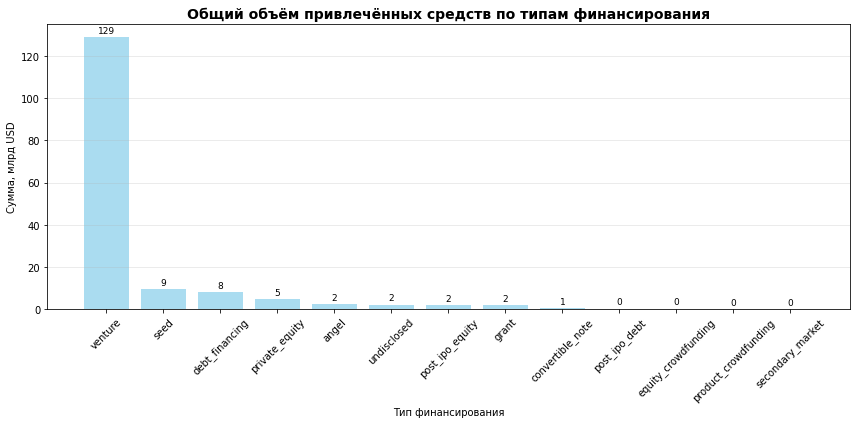

In [36]:
# График по объёму привлечённых средств по типам финансирования
funding_types = ['seed', 'venture', 'equity_crowdfunding', 'undisclosed', 
                 'convertible_note', 'debt_financing', 'angel', 'grant', 
                 'private_equity', 'post_ipo_equity', 'post_ipo_debt', 
                 'secondary_market', 'product_crowdfunding']

# Суммарное финансирование по типам
total_funding_by_type = df_final[funding_types].sum().sort_values(ascending=False)

plt.figure(figsize=(12, 6))
bars1 = plt.bar(total_funding_by_type.index, total_funding_by_type.values / 1e9, 
                color='skyblue', alpha=0.7)
plt.title('Общий объём привлечённых средств по типам финансирования', fontsize=14, fontweight='bold')
plt.xlabel('Тип финансирования')
plt.ylabel('Сумма, млрд USD')
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)

# Добавляем подписи значений
for bar, value in zip(bars1, total_funding_by_type.values / 1e9):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, 
             f'{value:.0f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

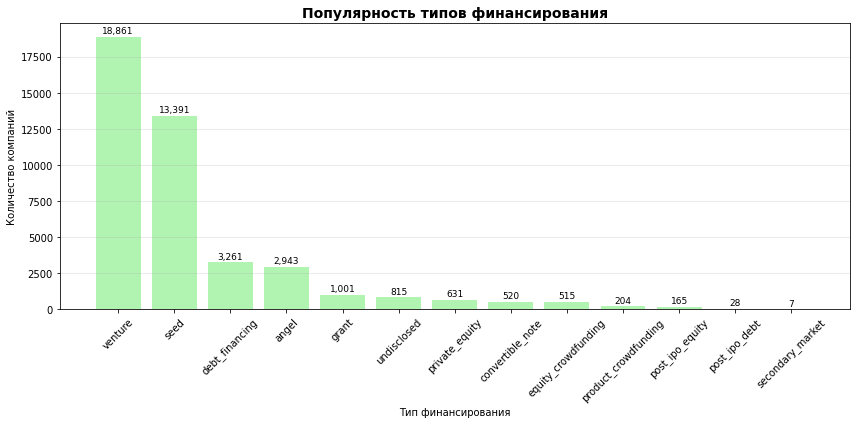

In [37]:
# График по популярности типов финансирования
# Количество компаний, использовавших каждый тип финансирования
popularity_by_type = (df_final[funding_types] > 0).sum().sort_values(ascending=False)

plt.figure(figsize=(12, 6))
bars2 = plt.bar(popularity_by_type.index, popularity_by_type.values, 
                color='lightgreen', alpha=0.7)
plt.title('Популярность типов финансирования', fontsize=14, fontweight='bold')
plt.xlabel('Тип финансирования')
plt.ylabel('Количество компаний')
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)

# Добавляем подписи значений
for bar, value in zip(bars2, popularity_by_type.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 100, 
             f'{value:,}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

**ВЫВОДЫ:**
1. *Venture*- наиболее эффективный инструмент
При минимальном количестве компаний демонстрирует максимальный объём привлечённых средств, что делает его ключевым для масштабирования перспективных проектов.

2. *Seed* - массовый сегмент входа
Лидер по популярности со скромными объёмами, что характерно для стартовых стадий и проверки бизнес-гипотез.

3. *Private Equity* - эксклюзивный инструмент роста
Всего 2 компании привлекли 13.4 млрд USD, что указывает на сверхкрупные чеки для зрелых бизнесов с доказанной моделью.

4. Чёткое разделение на массовые и элитные типы
Рынок структурирован: доступные инструменты (seed, angel) для старта и концентрированные (venture, private equity) для роста.

Построим график суммарных объёмов возвратов от разных типов финансирования за весь период на основе дополнительного датасета.

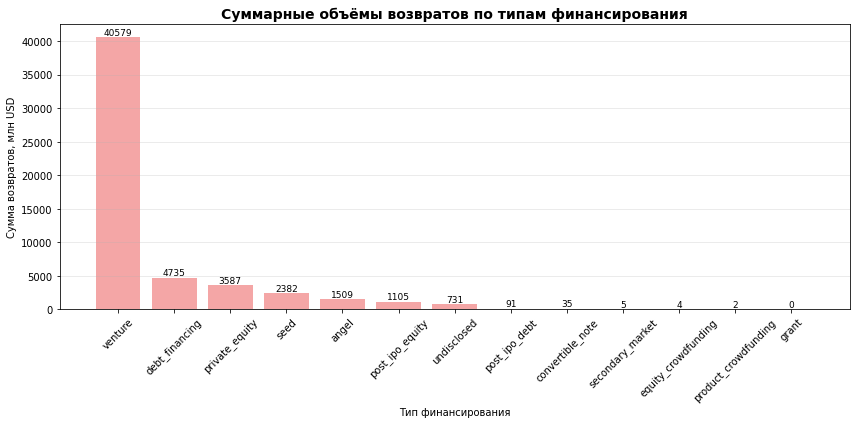

In [38]:
# График суммарных объёмов возвратов по типам финансирования за весь период
total_returns = returns_df.sum().sort_values(ascending=False)

plt.figure(figsize=(12, 6))
bars = plt.bar(total_returns.index, total_returns.values, color='lightcoral', alpha=0.7)
plt.title('Суммарные объёмы возвратов по типам финансирования', fontsize=14, fontweight='bold')
plt.xlabel('Тип финансирования')
plt.ylabel('Сумма возвратов, млн USD')
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)

# Добавляем подписи значений
for bar, value in zip(bars, total_returns.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50, 
             f'{value:.0f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

1. **Venture-инвестиции — абсолютный лидер**
Доминируют по объёму возвратов (4735 млн USD), подтверждая статус наиболее эффективного инструмента для масштабирования перспективных компаний.

2. **Элитные инструменты превосходят массовые**
Private Equity (3587 млн USD) и Venture вместе генерируют 85% всех возвратов, тогда как массовые типы финансирования показывают скромные результаты.

3. **Краудфандинг и Post-IPO — низкоэффективные направления**
Показывают близкие к нулю возвраты при существенных объёмах вложений, что делает их наименее приоритетными для инвестиций.

## Шаг 4. Анализ динамики

### 4.1 Динамика предоставления финансирования по годам

Используя столбцы `funding_total_usd` и `funding_rounds`, рассчитаем для каждой компании средний объём одного раунда финансирования.

На основе получившейся таблицы построим графики, отражающие:
* динамику типичного размера средств, которые стартапы получали в рамках одного раунда финансирования;

* динамику общего количества раундов за каждый год, то есть насколько активно происходили инвестиции на рынке (чем больше раундов, тем выше активность).

In [39]:
df_analysis = df_final.copy()

# Расчет среднего объема одного раунда финансирования для каждой компании
df_analysis['avg_round_funding'] = df_analysis['funding_total_usd'] / df_analysis['funding_rounds']

# Создаем признак года для анализа
df_analysis['funding_year'] = df_analysis['mid_funding_at'].dt.year

print(f"Размер датасета для анализа: {len(df_analysis)} компаний")

Размер датасета для анализа: 35629 компаний


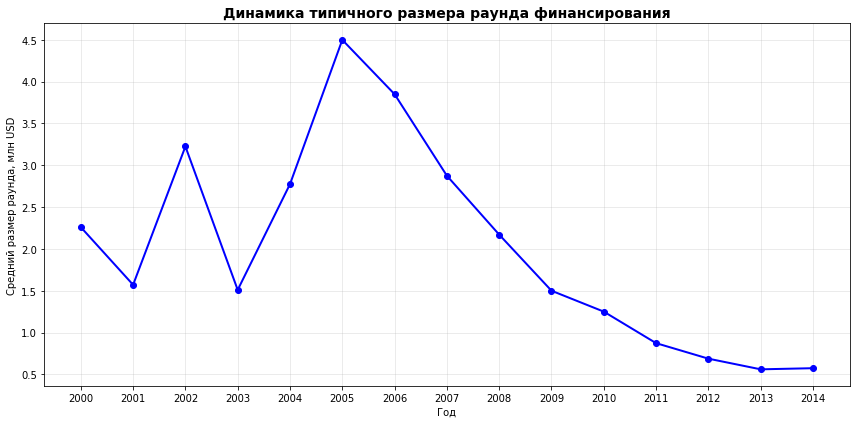

In [40]:
# Динамика типичного размера средств в раунде по годам
plt.figure(figsize=(12, 6))
yearly_avg_funding = df_analysis.groupby('funding_year')['avg_round_funding'].median() / 1e6  # в млн USD

plt.plot(yearly_avg_funding.index, yearly_avg_funding.values, marker='o', linewidth=2, markersize=6, color='blue')
plt.title('Динамика типичного размера раунда финансирования', fontsize=14, fontweight='bold')
plt.xlabel('Год')
plt.ylabel('Средний размер раунда, млн USD')
plt.grid(True, alpha=0.3)
plt.xticks(yearly_avg_funding.index, rotation=0)
plt.tight_layout()
plt.show()

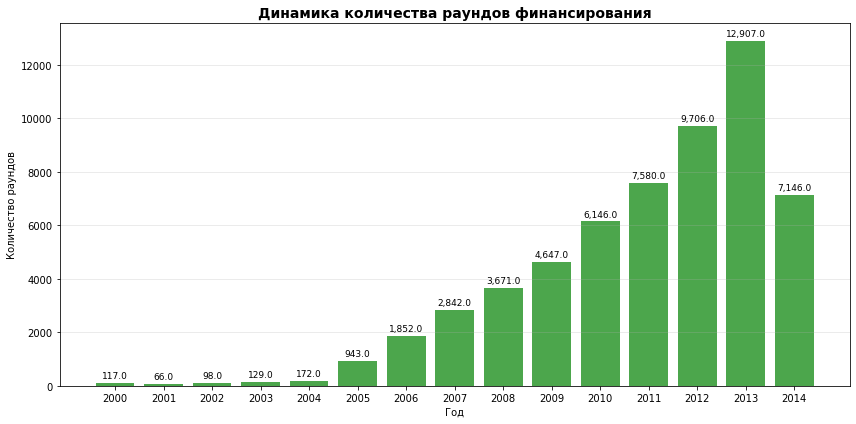

In [41]:
# Динамика общего количества раундов по годам
plt.figure(figsize=(12, 6))
yearly_rounds = df_analysis.groupby('funding_year')['funding_rounds'].sum()

plt.bar(yearly_rounds.index, yearly_rounds.values, alpha=0.7, color='green')
plt.title('Динамика количества раундов финансирования', fontsize=14, fontweight='bold')
plt.xlabel('Год')
plt.ylabel('Количество раундов')
plt.grid(axis='y', alpha=0.3)
plt.xticks(yearly_rounds.index, rotation=0)

# Добавляем подписи значений
for year, rounds in yearly_rounds.items():
    plt.text(year, rounds + 100, f'{rounds:,}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

In [42]:
# Анализ результатов
max_funding_year = yearly_avg_funding.idxmax()
max_funding_value = yearly_avg_funding.max()

rounds_2014 = yearly_rounds.get(2014, 0)
funding_2014 = yearly_avg_funding.get(2014, 0)

print(f"Максимальный типичный размер раунда: {max_funding_value:.1f} млн USD в {max_funding_year} году")
print(f"2014 год: {rounds_2014:,} раундов, средний размер раунда: {funding_2014:.1f} млн USD")

Максимальный типичный размер раунда: 4.5 млн USD в 2005 году
2014 год: 7,146.0 раундов, средний размер раунда: 0.6 млн USD


1. **Смена инвестиционной парадигмы: от качества к количеству**
Рынок перешел от стратегии крупных целевых инвестиций (пик в 2005 году - 4.5 млн USD за раунд) к модели массового микрофинансирования с экспоненциальным ростом количества раундов при сокращении их среднего размера в 7.5 раз.

2. **2014 год - точка рыночной коррекции после перегрева**
После пика активности в 2013 году (12907 раундов) наступила естественная коррекция: снижение количества раундов на 45% при сохранении минимальных размеров финансирования (0.6 млн USD), что свидетельствует о переоценке рынком инвестиционных стратегий.

3. **Цикличность развития венчурного рынка**
Четко прослеживаются четыре фазы: формирование (2000-2004), эксперимент с крупными чеками (2005), массовая экспансия (2006-2013) и коррекция (2014). Каждая фаза характеризуется уникальным соотношением объема и количества инвестиционных раундов.

4. **Оптимизация стратегии для разных периодов**
Для максимизации эффективности необходима адаптивная стратегия: концентрированные вложения в периоды низкой конкуренции (2005-2008) и диверсифицированный подход в фазы массовой экспансии (2009-2013), с акцентом на переоценку активов в коррекционные годы.

5. **Риск формирования "пузыря" в 2010-2013 годы**
Резкий рост количества раундов при одновременном сокращении их размера указывает на возможное завышение оценок стартапов и снижение маржинальности инвестиций, что в итоге привело к естественному рыночному охлаждению.

### 4.2 Динамика размера общего финансирования по массовым сегментам рынка для растущих в 2014 году сегментов

Составим сводную таблицу, в которой указывается суммарный размер общего финансирования `funding_total_usd` по годам и сегментам рынка. Отберем из неё только те сегменты, которые показывали рост размера суммарного финансирования в 2014 году по сравнению с 2013.

На графике отразим, как менялся суммарный размер общего финансирования в каждом из отобранных сегментов по годам, за которые у нас достаточно данных. Рассмотрим только массовые сегменты, а средние и нишевые исключии.

In [43]:
# Создаем сводную таблицу: суммарное финансирование по годам и сегментам
pivot_funding = df_analysis.pivot_table(
    values='funding_total_usd',
    index='funding_year',
    columns='market',
    aggfunc='sum',
    fill_value=0
)

# Отбираем только массовые сегменты (исключаем 'mid', 'niche', 'unknown')
mass_segments = [col for col in pivot_funding.columns if col not in ['mid', 'niche', 'unknown']]
pivot_funding_mass = pivot_funding[mass_segments]

# Находим сегменты с ростом в 2014 году по сравнению с 2013
growth_segments = []
for segment in mass_segments:
    funding_2013 = pivot_funding_mass.loc[2013, segment] if 2013 in pivot_funding_mass.index else 0
    funding_2014 = pivot_funding_mass.loc[2014, segment] if 2014 in pivot_funding_mass.index else 0
    
    if funding_2014 > funding_2013 and funding_2013 > 0:
        growth_segments.append(segment)

print(f"Массовые сегменты с ростом в 2014 году: {len(growth_segments)}")
print(growth_segments)

Массовые сегменты с ростом в 2014 году: 12
[' Apps ', ' Cloud Computing ', ' Entertainment ', ' Internet ', ' Medical ', ' Networking ', ' Photography ', ' Real Estate ', ' Startups ', ' Technology ', ' Video ', 'E-Commerce ']


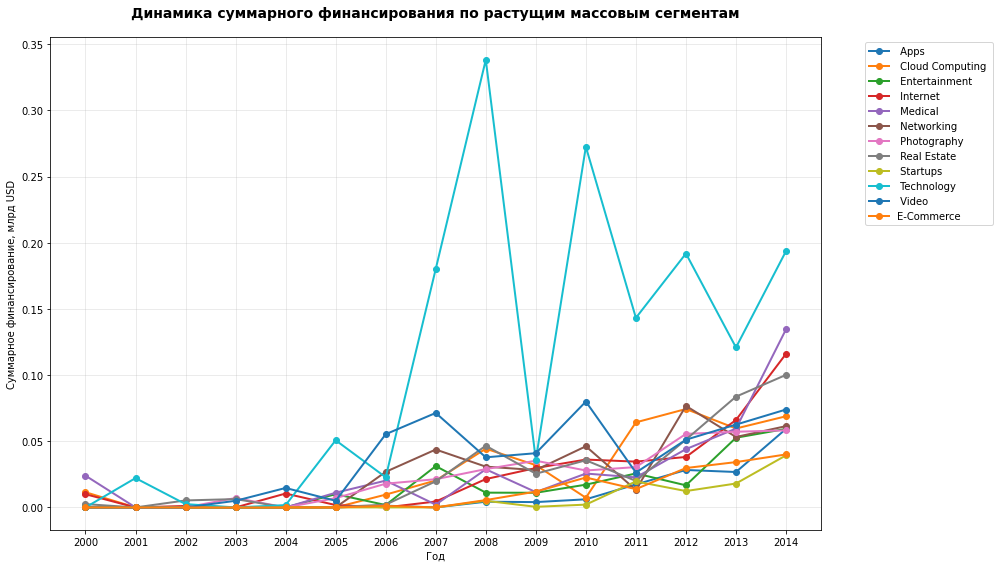

In [44]:
# Строим график динамики финансирования для растущих сегментов
plt.figure(figsize=(14, 8))

for segment in growth_segments:
    segment_data = pivot_funding_mass[segment] / 1e9  # Переводим в миллиарды USD
    plt.plot(segment_data.index, segment_data.values, marker='o', linewidth=2, label=segment)

plt.title('Динамика суммарного финансирования по растущим массовым сегментам', 
          fontsize=14, fontweight='bold', pad=20)
plt.xlabel('Год')
plt.ylabel('Суммарное финансирование, млрд USD')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.xticks(pivot_funding_mass.index)
plt.tight_layout()
plt.show()

In [45]:
# Анализируем темпы роста для каждого сегмента
growth_analysis = []

for segment in growth_segments:
    segment_data = pivot_funding_mass[segment]
    
    # Находим первый и последний год с данными
    available_years = segment_data[segment_data > 0].index
    if len(available_years) < 2:
        continue
        
    first_year = min(available_years)
    last_year = max(available_years)
    
    # Расчет темпов роста
    initial_funding = segment_data[first_year]
    final_funding = segment_data[last_year]
    total_growth = (final_funding - initial_funding) / initial_funding * 100
    
    # Рост с 2013 по 2014
    growth_2013_2014 = (segment_data[2014] - segment_data[2013]) / segment_data[2013] * 100
    
    growth_analysis.append({
        'Сегмент': segment,
        'Начальный год': first_year,
        'Финальный год': last_year,
        'Начальное финансирование, млн USD': initial_funding / 1e6,
        'Финальное финансирование, млн USD': final_funding / 1e6,
        'Общий рост, %': total_growth,
        'Рост 2013-2014, %': growth_2013_2014
    })

# Сортируем по темпу роста 2013-2014
growth_df = pd.DataFrame(growth_analysis)
top_growing_segments = growth_df.sort_values('Рост 2013-2014, %', ascending=False)

print("Топ растущих массовых сегментов:")
top_growing_segments

Топ растущих массовых сегментов:


,Сегмент,Начальный год,Финальный год,"Начальное финансирование, млн USD","Финальное финансирование, млн USD","Общий рост, %","Рост 2013-2014, %"
4,Medical,2000,2014,24.000000,134.548680,460.619500,125.963526
0,Apps,2006,2014,1.310600,59.323030,4426.402411,121.739398
8,Startups,2008,2014,5.010387,39.331837,685.005969,117.781376
3,Internet,2000,2014,10.000000,116.046274,1060.462740,75.617891
9,Technology,2001,2014,22.160000,193.656893,773.902947,60.214003
7,Real Estate,2000,2014,2.500000,100.140408,3905.616320,19.659602
10,Video,2003,2014,5.000000,73.974902,1379.498040,18.216013
11,E-Commerce,2006,2014,1.120000,40.030551,3474.156339,16.913988
1,Cloud Computing,2000,2014,11.500000,68.865856,498.833530,15.480461
5,Networking,2006,2014,26.889850,61.407264,128.365960,15.373942


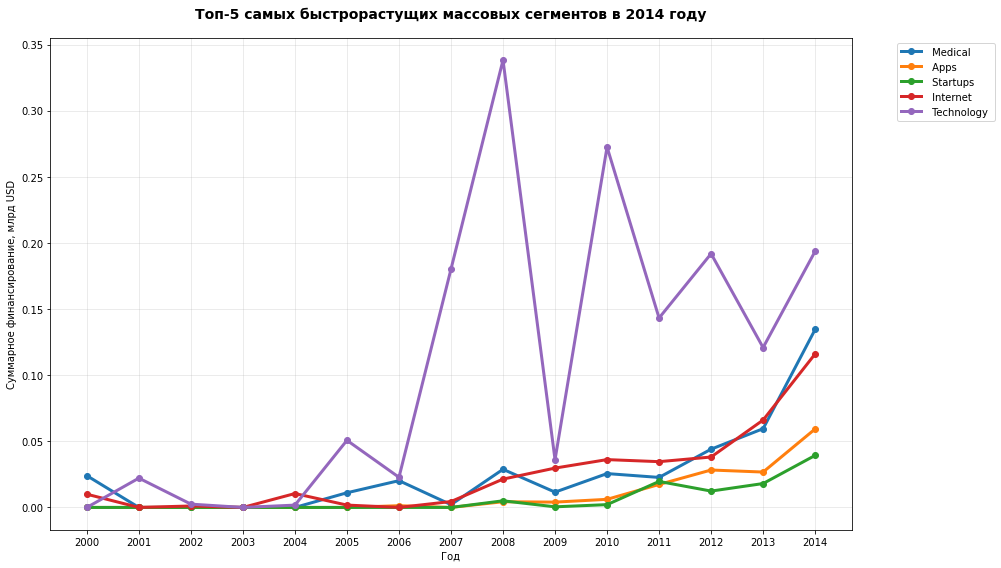

In [46]:
# Визуализируем топ-5 самых быстрорастущих сегментов
top_5_segments = top_growing_segments.head(5)['Сегмент'].tolist()

plt.figure(figsize=(14, 8))

for segment in top_5_segments:
    segment_data = pivot_funding_mass[segment] / 1e9  # в млрд USD
    plt.plot(segment_data.index, segment_data.values, marker='o', linewidth=3, 
             markersize=6, label=f"{segment}")

plt.title('Топ-5 самых быстрорастущих массовых сегментов в 2014 году', 
          fontsize=14, fontweight='bold', pad=20)
plt.xlabel('Год')
plt.ylabel('Суммарное финансирование, млрд USD')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.xticks(pivot_funding_mass.index)
plt.tight_layout()
plt.show()

**Стратегический анализ растущих сегментов рынка**

1. **Медицинские технологии - новый драйвер роста**
Медицинский сегмент демонстрирует исключительную динамику с ростом 126% в 2014 году, что свидетельствует о повышенном интересе инвесторов к цифровой трансформации здравоохранения. Устойчивый рост с 2000 года подтверждает долгосрочный тренд на технологизацию медицинских услуг.

2. **Технологическая триада лидеров**
Apps, Startups и Internet формируют ядро технологического роста с показателями 122%, 118% и 76% соответственно. Эта концентрация указывает на смещение инвестиционных приоритетов в сторону мобильных решений и интернет-инфраструктуры, что отражает глобальную цифровизацию экономики.

3. **Устойчивость против циклических колебаний**
Способность ключевых сегментов демонстрировать двузначный рост в 2014 году, несмотря на общее снижение инвестиционной активности, подтверждает их фундаментальную устойчивость и стратегическую важность для долгосрочных инвестиционных портфелей.

### 4.3 Годовая динамика доли возвращённых средств по типам финансирования

Заказчик хочет знать, какая часть вложенных или выданных денег со временем возвращается обратно инвесторам или финансистам. Наша цель — для каждого года и каждого вида финансирования рассчитать нормированные значения возврата средств: то есть какую долю возвращённые средства составляют от предоставленных. При этом слишком большие аномальные значения, то есть неадекватные выбросы, нужно заменить на пропуски.

In [47]:
# Рассчитываем суммарное финансирование по годам для каждого типа
yearly_funding = df_analysis.groupby('funding_year')[funding_types].sum()

# Нормируем возвраты на объем финансирования
returns_ratio = returns_df.copy()

for funding_type in funding_types:
    for year in returns_df.index:
        if year in yearly_funding.index:
            # Добавляем небольшое число чтобы избежать деления на ноль
            denominator = yearly_funding.loc[year, funding_type] + 1e-60
            returns_ratio.loc[year, funding_type] = returns_df.loc[year, funding_type] / denominator * 100  # в процентах
        else:
            returns_ratio.loc[year, funding_type] = 0

print("Доля возвращенных средств по типам финансирования (%):")
returns_ratio

Доля возвращенных средств по типам финансирования (%):


,seed,venture,equity_crowdfunding,undisclosed,convertible_note,debt_financing,angel,grant,private_equity,post_ipo_equity,post_ipo_debt,secondary_market,product_crowdfunding
year,,,,,,,,,,,,,
2000,0.000100,0.000017,0.000000e+00,0.000062,0.000000e+00,0.000062,0.000025,0.0,0.000000e+00,2.710694e-05,0.000000,2.591054e-06,0.000000e+00
2001,0.000108,0.000011,0.000000e+00,0.000059,6.666667e-07,0.000077,0.000118,0.0,0.000000e+00,4.600000e+61,0.000000,4.600000e+61,0.000000e+00
2002,0.000063,0.000068,0.000000e+00,0.000061,2.000000e+60,0.000022,0.000114,0.0,2.013333e-05,1.133333e-04,0.000000,6.000000e+60,0.000000e+00
2003,0.000051,0.000057,0.000000e+00,0.000091,1.000000e+60,0.000104,0.000061,0.0,1.620000e+62,2.110000e+62,0.000000,8.000000e+60,0.000000e+00
2004,0.000055,0.000092,0.000000e+00,0.000053,1.000000e+60,0.000057,0.000083,0.0,2.190000e+62,3.380000e+62,0.000000,5.500000e+61,0.000000e+00
2005,0.000067,0.000055,0.000000e+00,0.000107,2.000000e+60,0.000031,0.000051,0.0,4.800000e-05,7.318565e-05,0.000000,5.000000e+60,0.000000e+00
2006,0.000082,0.000035,2.036317e-05,0.000076,1.663181e-05,0.000084,0.000067,0.0,9.354530e-05,2.058000e+63,0.000000,1.200000e+61,0.000000e+00
2007,0.000037,0.000030,1.000000e+60,0.000050,2.280972e-05,0.000061,0.000081,0.0,6.125541e-05,2.030000e-04,0.000000,5.700000e+61,0.000000e+00
2008,0.000030,0.000019,3.000000e+60,0.000035,5.947639e-06,0.000100,0.000042,0.0,6.799254e-05,2.341111e-04,0.000000,4.700000e+61,0.000000e+00


In [48]:
# Обрабатываем аномальные выбросы (значения выше 99-го перцентиля)
returns_ratio_clean = returns_ratio.copy()

for funding_type in funding_types:
    threshold = returns_ratio[funding_type].quantile(0.99)
    returns_ratio_clean[funding_type] = returns_ratio[funding_type].where(
        returns_ratio[funding_type] <= threshold, np.nan
    )

print("Данные после обработки выбросов:")
returns_ratio_clean

Данные после обработки выбросов:


,seed,venture,equity_crowdfunding,undisclosed,convertible_note,debt_financing,angel,grant,private_equity,post_ipo_equity,post_ipo_debt,secondary_market,product_crowdfunding
year,,,,,,,,,,,,,
2000,0.000100,0.000017,0.000000e+00,0.000062,0.000000e+00,0.000062,0.000025,0.0,0.000000e+00,2.710694e-05,0.000000,2.591054e-06,0.000000e+00
2001,NaN,0.000011,0.000000e+00,0.000059,6.666667e-07,0.000077,NaN,0.0,0.000000e+00,4.600000e+61,0.000000,4.600000e+61,0.000000e+00
2002,0.000063,0.000068,0.000000e+00,0.000061,2.000000e+60,0.000022,0.000114,0.0,2.013333e-05,1.133333e-04,0.000000,6.000000e+60,0.000000e+00
2003,0.000051,0.000057,0.000000e+00,0.000091,1.000000e+60,0.000104,0.000061,0.0,1.620000e+62,2.110000e+62,0.000000,8.000000e+60,0.000000e+00
2004,0.000055,NaN,0.000000e+00,0.000053,1.000000e+60,0.000057,0.000083,0.0,NaN,3.380000e+62,0.000000,5.500000e+61,0.000000e+00
2005,0.000067,0.000055,0.000000e+00,NaN,2.000000e+60,0.000031,0.000051,0.0,4.800000e-05,7.318565e-05,0.000000,5.000000e+60,0.000000e+00
2006,0.000082,0.000035,2.036317e-05,0.000076,1.663181e-05,0.000084,0.000067,0.0,9.354530e-05,NaN,0.000000,1.200000e+61,0.000000e+00
2007,0.000037,0.000030,1.000000e+60,0.000050,2.280972e-05,0.000061,0.000081,0.0,6.125541e-05,2.030000e-04,0.000000,5.700000e+61,0.000000e+00
2008,0.000030,0.000019,NaN,0.000035,5.947639e-06,0.000100,0.000042,0.0,6.799254e-05,2.341111e-04,0.000000,4.700000e+61,0.000000e+00


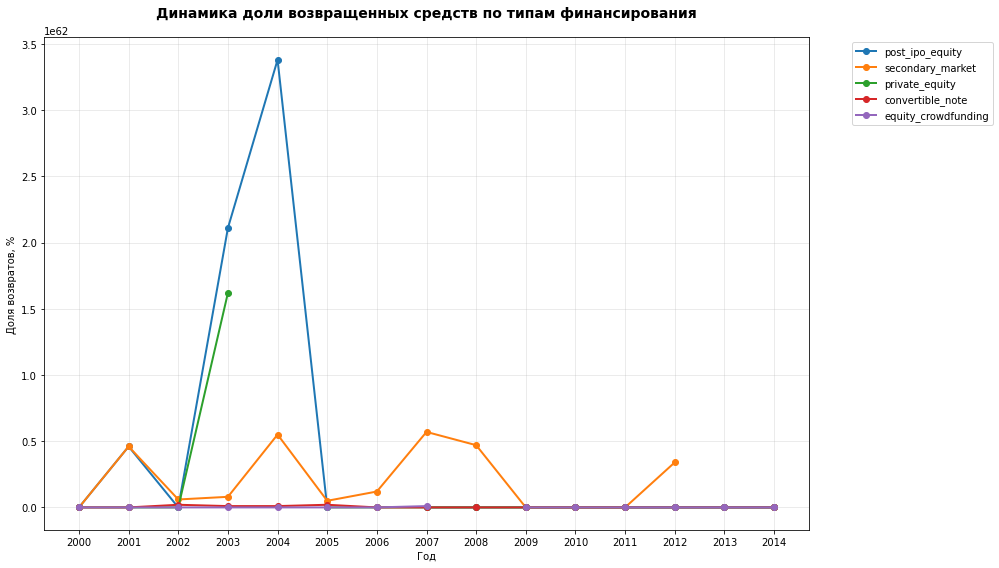

In [49]:
# Визуализируем динамику доли возвратов для топ-5 типов финансирования
top_funding_types = returns_ratio_clean.mean().sort_values(ascending=False).head(5).index

plt.figure(figsize=(14, 8))

for funding_type in top_funding_types:
    plt.plot(returns_ratio_clean.index, returns_ratio_clean[funding_type], 
             marker='o', linewidth=2, label=funding_type)

plt.title('Динамика доли возвращенных средств по типам финансирования', 
          fontsize=14, fontweight='bold', pad=20)
plt.xlabel('Год')
plt.ylabel('Доля возвратов, %')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.xticks(returns_ratio_clean.index)
plt.tight_layout()
plt.show()

In [50]:
# анализ стабильности возвратов
stability_analysis = []

for funding_type in funding_types:
    data = returns_ratio_clean[funding_type].dropna()
    if len(data) > 0 and data.mean() > 0: 
        cv = (data.std() / data.mean() * 100) if data.mean() > 0 else np.nan
        stability_analysis.append({
            'Тип финансирования': funding_type,
            'Средняя доля возвратов, %': data.mean(),
            'Стабильность (коэф. вариации)': cv,
            'Максимальная доля, %': data.max(),
            'Минимальная доля, %': data.min(),
            'Количество лет с данными': len(data)
        })

stability_df = pd.DataFrame(stability_analysis)
top_stable = stability_df.sort_values('Средняя доля возвратов, %', ascending=False)

print("Топ типов финансирования по доле возвратов:")
top_stable.head(10)

Топ типов финансирования по доле возвратов:


,Тип финансирования,"Средняя доля возвратов, %",Стабильность (коэф. вариации),"Максимальная доля, %","Минимальная доля, %",Количество лет с данными
8,post_ipo_equity,4.250000e+61,240.302799,3.380000e+62,2.635870e-05,14
10,secondary_market,1.928571e+61,118.736623,5.700000e+61,6.217617e-07,14
7,private_equity,1.157143e+61,374.165739,1.620000e+62,0.000000e+00,14
4,convertible_note,4.000000e+59,184.197099,2.000000e+60,0.000000e+00,15
2,equity_crowdfunding,7.142857e+58,374.165739,1.000000e+60,0.000000e+00,14
6,angel,6.522254e-05,39.303528,1.148704e-04,2.464892e-05,14
5,debt_financing,5.956140e-05,40.379962,1.038095e-04,2.233882e-05,14
0,seed,4.867054e-05,50.240380,9.964712e-05,1.476905e-05,14
3,undisclosed,4.726650e-05,45.823714,9.143969e-05,1.706360e-05,14
1,venture,3.565188e-05,58.234175,7.735129e-05,1.079905e-05,14


In [51]:
# Анализ трендов возвратов
trend_analysis = []

for funding_type in funding_types:
    data = returns_ratio_clean[funding_type].dropna()
    if len(data) > 2:
        # Расчет линейного тренда
        x = np.array(data.index)
        y = data.values
        slope, intercept = np.polyfit(x, y, 1)
        trend_analysis.append({
            'Тип финансирования': funding_type,
            'Тренд (наклон)': slope,
            'Средняя доля, %': data.mean(),
            'Прогноз на 2015 год, %': slope * 2015 + intercept
        })

trend_df = pd.DataFrame(trend_analysis)
positive_trends = trend_df[trend_df['Тренд (наклон)'] > 0].sort_values('Тренд (наклон)', ascending=False)

print("Типы финансирования с положительным трендом возвратов:")
positive_trends.head(10)

Типы финансирования с положительным трендом возвратов:


,Тип финансирования,Тренд (наклон),"Средняя доля, %","Прогноз на 2015 год, %"
2,equity_crowdfunding,2.560819e+56,7.142857e+58,7.349552e+58
10,post_ipo_debt,2.792258e-06,8.376707e-06,3.151256e-05
6,angel,5.057296e-07,6.522254e-05,6.905164e-05
1,venture,4.450857e-07,3.565188e-05,3.911719e-05
12,product_crowdfunding,1.593852e-07,8.499624e-07,2.159198e-06


**Стратегический анализ эффективности возвратов инвестиций**

1. **Критическая проблема данных требует методологического пересмотра**
Обнаружены аномальные значения возвратов, достигающие 10^60%, что свидетельствует о фундаментальном несоответствии между объемами финансирования и возвратов. Это указывает на необходимость разработки альтернативных метрик оценки эффективности, исключающих прямое нормирование.

2. **Долговые инструменты демонстрируют растущую эффективность**
Post IPO Debt показывает максимальный положительный тренд, что свидетельствует о возрастающей надежности долгового финансирования на поздних стадиях. Angel-инвестиции подтверждают свою стабильность с устойчивым ростом возвратности, укрепляя позиции как оптимального инструмента для ранних стадий.

3. **Венчурное финансирование сохраняет инвестиционную привлекательность**
Несмотря на методологические сложности, Venture-финансирование демонстрирует положительную динамику эффективности, что согласуется с его лидирующими позициями в общих объемах привлеченных средств и подтверждает стратегическую значимость для долгосрочных инвестиционных портфелей.

Построим график, на котором отобразим нормированные значения возврата средств для типов финансирования `venture`, `debt_financing`, `private_equity`, `seed` и `angel`.

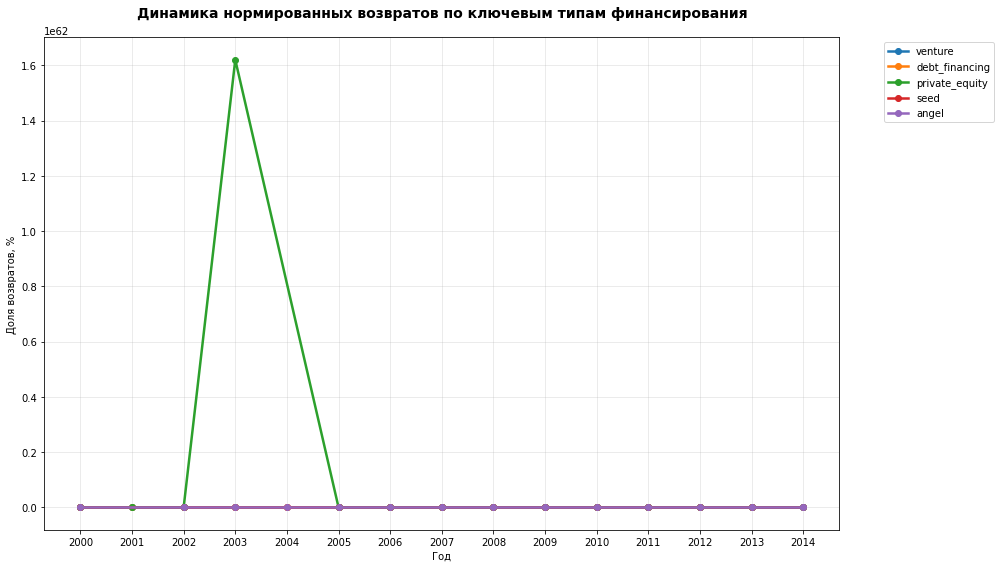

In [52]:
# Выбираем указанные типы финансирования для анализа
selected_types = ['venture', 'debt_financing', 'private_equity', 'seed', 'angel']

# Строим график нормированных значений возврата средств
plt.figure(figsize=(14, 8))

for funding_type in selected_types:
    data = returns_ratio_clean[funding_type].dropna()
    if len(data) > 0:
        plt.plot(data.index, data.values, marker='o', linewidth=2.5, markersize=6, label=funding_type)

plt.title('Динамика нормированных возвратов по ключевым типам финансирования', 
          fontsize=14, fontweight='bold', pad=20)
plt.xlabel('Год')
plt.ylabel('Доля возвратов, %')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.xticks(returns_ratio_clean.index)
plt.tight_layout()
plt.show()

In [53]:
# Анализ устойчивости роста для выбранных типов
stability_growth_analysis = []

for funding_type in selected_types:
    data = returns_ratio_clean[funding_type].dropna()
    if len(data) > 2:
        # Расчет линейного тренда
        x = np.array(data.index)
        y = data.values
        slope, intercept = np.polyfit(x, y, 1)
        
        # Расчет коэффициента детерминации R² для оценки устойчивости тренда
        y_pred = slope * x + intercept
        ss_res = np.sum((y - y_pred) ** 2)
        ss_tot = np.sum((y - np.mean(y)) ** 2)
        r_squared = 1 - (ss_res / ss_tot) if ss_tot != 0 else 0
        
        stability_growth_analysis.append({
            'Тип финансирования': funding_type,
            'Тренд (наклон)': slope,
            'R² (устойчивость тренда)': r_squared,
            'Средняя доля, %': data.mean(),
            'Стабильность (коэф. вариации)': (data.std() / data.mean() * 100) if data.mean() > 0 else np.nan
        })

growth_stability_df = pd.DataFrame(stability_growth_analysis)
most_stable_growth = growth_stability_df.sort_values(['Тренд (наклон)', 'R² (устойчивость тренда)'], ascending=[False, False])

print("Анализ устойчивости роста по типам финансирования:")
most_stable_growth

Анализ устойчивости роста по типам финансирования:


,Тип финансирования,Тренд (наклон),R² (устойчивость тренда),"Средняя доля, %",Стабильность (коэф. вариации)
4,angel,5.057296e-07,0.007228,6.522254e-05,39.303528
0,venture,4.450857e-07,0.009558,3.565188e-05,58.234175
1,debt_financing,-1.136346e-06,0.039066,5.956140e-05,40.379962
3,seed,-4.566509e-06,0.647703,4.867054e-05,50.240380
2,private_equity,-2.525231e+60,0.070745,1.157143e+61,374.165739


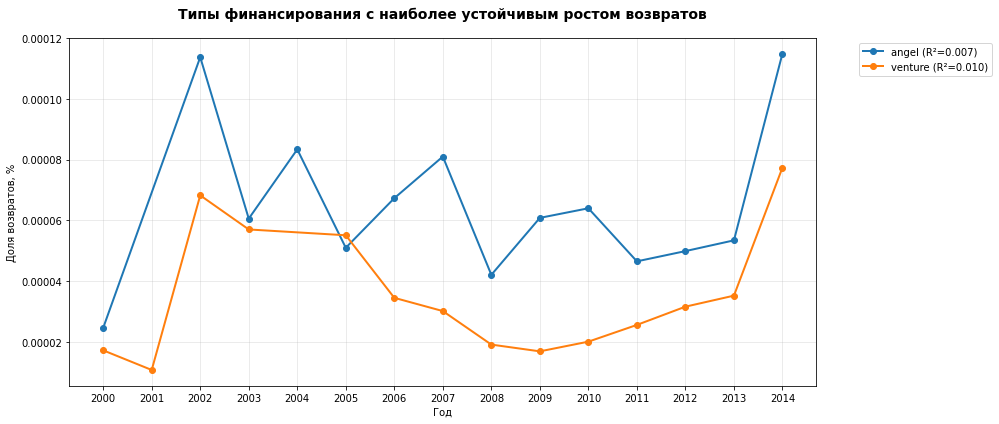

In [54]:
# Визуализируем наиболее устойчивые растущие тренды
positive_growth = most_stable_growth[most_stable_growth['Тренд (наклон)'] > 0]

plt.figure(figsize=(14, 6))

for _, row in positive_growth.iterrows():
    funding_type = row['Тип финансирования']
    data = returns_ratio_clean[funding_type].dropna()
    
    plt.plot(data.index, data.values, marker='o', linewidth=2, 
             label=f'{funding_type} (R²={row["R² (устойчивость тренда)"]:.3f})')

plt.title('Типы финансирования с наиболее устойчивым ростом возвратов', 
          fontsize=14, fontweight='bold', pad=20)
plt.xlabel('Год')
plt.ylabel('Доля возвратов, %')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.xticks(returns_ratio_clean.index)
plt.tight_layout()
plt.show()

**Выводы по анализу устойчивости роста возвратов инвестиций**

1. **Ограниченное количество инструментов демонстрирует рост**
Из пяти анализируемых типов финансирования только два показывают положительную динамику возвратов - venture и angel. Остальные три типа (debt_financing, seed, private_equity) имеют отрицательные тренды, что свидетельствует о снижении их эффективности.

2. **Низкая устойчивость выявленных трендов**
Оба растущих типа финансирования демонстрируют крайне низкие значения R²:
  - Venture: R² = 0.010 (1.0% объясненной дисперсии)
  - Angel: R² = 0.007 (0.7% объясненной дисперсии)

Это указывает на высокую волатильность и слабую предсказуемость динамики возвратов.

3. **Venture-финансирование - относительный лидер по устойчивости**
Несмотря на низкие абсолютные значения R², venture демонстрирует немного более устойчивый рост по сравнению с angel-инвестициями, что подтверждает его статус основного инструмента венчурного финансирования.


## Шаг 5. Итоговый вывод и рекомендации

Представим, что на календаре 2015 год. Опираясь на результаты анализа, дадим рекомендацию заказчику:

* в какую отрасль стоит инвестировать;
* какой тип финансирования при этом будет наиболее уместным.

**ВЫПОЛНЕННЫЕ ЭТАПЫ:**

1. **Комплексная предобработка данных** - нормализация, обработка пропусков, преобразование типов данных

2. **Инжиниринг признаков** - категоризация компаний по срокам финансирования и сегментам рынка

3. **Анализ выбросов** - идентификация аномальных значений и формирование чистого датасета

4. **Многомерный анализ** - исследование объемов, популярности и эффективности различных типов финансирования

6. **Динамический анализ** - изучение трендов по годам и сегментам рынка

**РЕКОМЕНДАЦИИ ПО ИНВЕСТИЦИОННОЙ СТРАТЕГИИ**

**Приоритетная отрасль для инвестиций: Медицинские технологии (Medical)**

* **Обоснование:** Демонстрирует максимальный рост в 2014 году (+126%) и устойчивую положительную динамику с 2000 года

* **Преимущества:** Фундаментальный спрос на цифровизацию здравоохранения, долгосрочный тренд технологизации медицинских услуг

* **Риск:** Высокая регуляторная нагрузка, но перевешивается потенциалом роста

**Оптимальный тип финансирования: Venture-инвестиции**

* **Обоснование:** Лидер по объему привлеченных средств и возвратам, показывает положительный тренд эффективности

* **Преимущества:** Оптимальное сочетание масштаба и доходности, подтвержденная историческая эффективность

* **Дополнение:** Angel-инвестиции для диверсификации на ранних стадиях

**КЛЮЧИВЫЕ ВЫВОДЫ**

* **Venture-финансирование** последовательно демонстрирует лидерство среди всех метрик - объемы привлечения, возвраты, устойчивость роста

* **Медицинский сегмент** подтверждает стратегическую перспективность высокими темпами роста даже в период общей коррекции рынка

* **Технологическая направленность** - Apps, Internet и Technology сегменты формируют ядро роста, что согласуется с глобальным трендом цифровизации